<a href="https://colab.research.google.com/github/Saifuddin-Yasir/ML-AI-Learning-Journey/blob/main/Final_ML_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Loading**

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data_un= pd.read_csv('/content/water_potability.csv')

In [ ]:
data_un.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


# **Data Preprocessing**

In [ ]:
data_un.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


In [ ]:
data_un.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [ ]:
#FILL MISSING VALUES
from sklearn.impute import SimpleImputer
imputer_mean= SimpleImputer(strategy='mean')

data_un['ph']= imputer_mean.fit_transform(data_un[['ph']])
data_un['Sulfate']= imputer_mean.fit_transform(data_un[['Sulfate']])
data_un['Trihalomethanes']= imputer_mean.fit_transform(data_un[['Trihalomethanes']])


In [ ]:
data_un.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [ ]:
# Encoding

## there are all column data in numerical data in numerical form. So, it's don't need encoding

In [ ]:
# Scaling

from sklearn.preprocessing import RobustScaler
scaler= RobustScaler()

x= data_un.drop('Potability', axis=1)
y= data_un['Potability']

x_scaled= scaler.fit_transform(x)

In [ ]:
data= pd.DataFrame(x_scaled, columns=x.columns)
data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.000000,0.198981,-0.011702,0.085492,1.043542,1.227178,-0.854560,1.028759,-0.935210
1,-2.113014,-1.696382,-0.196962,-0.249088,0.000000,1.473406,0.214093,-0.502884,0.514449
2,0.639503,0.684850,-0.087287,1.079558,0.000000,-0.028251,0.590024,0.001189,-0.847715
3,0.776180,0.437145,0.093483,0.467446,0.694190,-0.505079,0.939076,1.695662,0.635242
4,1.263161,-0.398477,-0.252771,-0.293690,-0.710100,-0.202262,-0.592197,-1.718287,0.113188


before remove outliers : 
ph                 142
Hardness            83
Solids              47
Chloramines         61
Sulfate            264
Conductivity        11
Organic_carbon      25
Trihalomethanes     54
Turbidity           19
dtype: int64


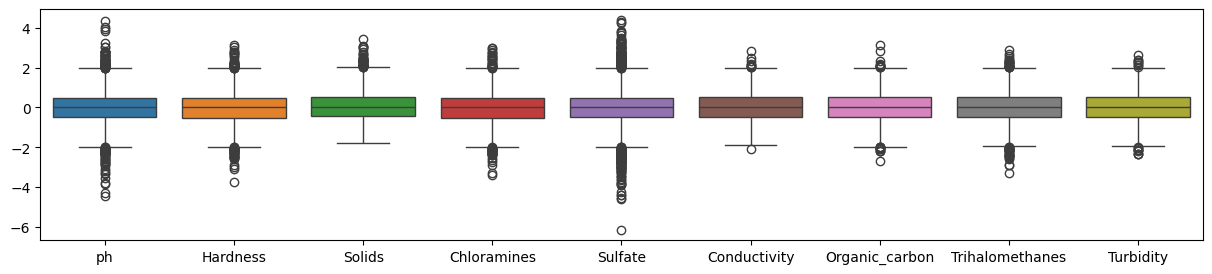

In [ ]:
# Outliers

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,3))
sns.boxplot(data=data)

q1= data.quantile(0.25)
q3= data.quantile(0.75)
iqr= q3-q1
upper= q3+1.5*iqr
lower= q1-1.5*iqr
print(f'before remove outliers : \n{((data<= lower) | (data >= upper)).sum()}')

In [ ]:
datas=pd.DataFrame()

for i in data.columns:
  q1= data[i].quantile(0.25)
  q3= data[i].quantile(0.75)
  iqr= q3-q1

  upper= q3+1.5*iqr
  lower= q1-1.5*iqr
  datas[i] = ((data[i] >= lower) & (data[i] <= upper))

data=datas

In [ ]:
print(f'After remove outliers : \n{((data<= lower) | (data >= upper)).sum()}')

After remove outliers : 
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64


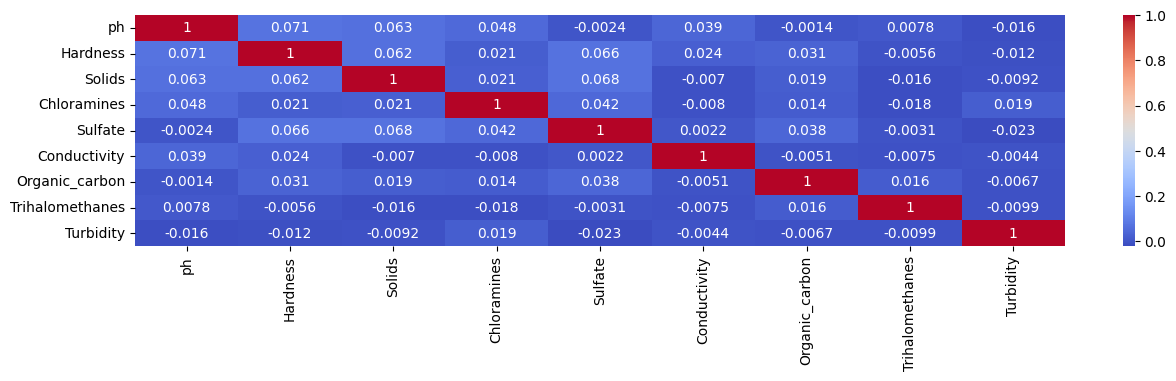

In [ ]:
# Features Engineering

# here, I have done handling missing values and robust scaling. There are no additional features engineering.creation and binning necessaary. Those features are individually informative.

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(data,title="WATER POTABILITY PREDICTOR",explorative = True )
profile.to_file("ydata_water_potability.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 274.16it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#**Pipeline Creation & Model Training**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

x= data_un.drop('Potability', axis=1)
y = y
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,stratify=y,random_state=42)

#PIPELINE FOR EACH MODEL
pip_lr = Pipeline(
    [
        ("preprocessing", RobustScaler()),
        ('model', LogisticRegression())
    ]
)
lr_param= {
    "model__C":[0.1,1,10],
    "model__penalty": ["l2"],
    "model__max_iter": [500, 1000]
}

pip_rfc = Pipeline(
    [
        ('model', RandomForestClassifier())
    ]
)
rfc_param= {
    "model__n_estimators":[50,100,300,400],
    "model__max_depth":[3,5]
}

pip_svc = Pipeline(
    [
        ("preprocessing", RobustScaler()),
        ('model', SVC())
    ]
)

svc_param= {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf' ],
    'model__gamma': [0.01, 0.1, 1,100]
}

pipe_nb = Pipeline([
    ('model', GaussianNB())
])

nb_param = {}

pip_knn = Pipeline(
    [
        ("preprocessing", RobustScaler()),
        ('model', KNeighborsClassifier())
    ]
)
knn_param= {
    'model__n_neighbors': [3,5,10,15,20,25],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}


pipe_xgb = Pipeline([
       ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_param = {
    'model__n_estimators': [100,200, 400],
    'model__max_depth': [2, 3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

# MODEL WITH ALL GIVEN PARAMETER
Model_param = {
    'RandomForestClassifier': [pip_rfc, rfc_param],
    'XGBClassifier': [pipe_xgb, xgb_param],
    'GaussianNB': [pipe_nb, nb_param],
    'LogisticRegression': [pip_lr, lr_param],
    'SVC': [pip_svc, svc_param],
    'KNeighborsClassifier': [pip_knn, knn_param]
}


results = {}

for name ,(model,param) in Model_param.items():
  grid= GridSearchCV(model,param,cv=5,scoring='accuracy')
  grid.fit(x_train,y_train)
  y_pred= grid.predict(x_test)

  results[name] = {
        'Best Params': grid.best_params_ ,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred) ,
        "ROC AUC": roc_auc_score(y_test, y_pred)
    }

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
pd.DataFrame(results).T.sort_values(by='Accuracy', ascending=False)

,Best Params,Accuracy,F1 Score,Precision,Recall,ROC AUC
SVC,"{'model__C': 10, 'model__gamma': 0.1, 'model__...",0.667888,0.451613,0.636364,0.35,0.610872
KNeighborsClassifier,"{'model__metric': 'euclidean', 'model__n_neigh...",0.650794,0.331776,0.657407,0.221875,0.573863
RandomForestClassifier,"{'model__max_depth': 5, 'model__n_estimators':...",0.644689,0.224,0.763636,0.13125,0.552599
XGBClassifier,"{'model__colsample_bytree': 1.0, 'model__learn...",0.642247,0.441905,0.565854,0.3625,0.592072
LogisticRegression,"{'model__C': 0.1, 'model__max_iter': 500, 'mod...",0.60928,0.0,0.0,0.0,0.5
GaussianNB,{},0.606838,0.26484,0.491525,0.18125,0.530505


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


# **Primary Model Selection**

Here, i select SVC as primary model.Because, it work well at non-linear data with scaling. in class imbalance, it showed robustness by maximixation margin by using it's parameter. Also,we got SVC have higher recall and accuracy than other model.

# **Cross Validation**

In [ ]:
scaler= RobustScaler()
x_train= scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [ ]:
from sklearn.model_selection import cross_val_score
# Here Recall is More important,so we did scoring recall

svc_model = SVC(C=10,gamma=0.1,kernel="rbf",class_weight='balanced')
scores = cross_val_score(svc_model, x_train, y_train, cv=30, scoring='recall')

average_score = np.mean(scores)
std_dev = np.std(scores)

print("Cross-Validation Scores:", scores)
print("Average Accuracy: " ,(average_score))
print("Standard Deviation: ", (std_dev))


Cross-Validation Scores: [0.65625    0.71875    0.53125    0.71875    0.59375    0.59375
 0.5625     0.625      0.5        0.4375     0.6875     0.5
 0.6875     0.59375    0.375      0.53125    0.53125    0.625
 0.5625     0.40625    0.5625     0.5        0.625      0.5625
 0.40625    0.59375    0.6875     0.67741935 0.5483871  0.65625   ]
Average Accuracy:  0.5752352150537633
Standard Deviation:  0.09159769348989055


# **Hyperparameter Tuning**

In [ ]:
svmm_model = SVC()
from sklearn.model_selection import RandomizedSearchCV
param= [

    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10],
        'gamma': [0.01, 0.1, 1]
    }
]
grid_search = grid_search = RandomizedSearchCV(
    svmm_model,param, n_iter=5,scoring='accuracy',cv=2,n_jobs=-1, random_state=42
)

grid_search.fit(x_train, y_train)
print(grid_search.best_params_)

{'kernel': 'rbf', 'gamma': 0.1, 'C': 10}


# **Best Model Selection & Model Permormance Evaluation**

In [ ]:
best_model = SVC(
        kernel='rbf',
        C=10,
        gamma=0.1,
        class_weight='balanced',
        random_state=42
    )


pipeline= Pipeline([
   ('Model', best_model)
                    ])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")
print(f"precision: {precision_score(y_test, y_pred)}")
print(f"recall: {recall_score(y_test, y_pred)}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred)}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6214896214896215
F1 Score: 0.49838187702265374
precision: 0.5167785234899329
recall: 0.48125
ROC AUC: 0.5963364228456913
[[355 144]
 [166 154]]
              precision    recall  f1-score   support

           0       0.68      0.71      0.70       499
           1       0.52      0.48      0.50       320

    accuracy                           0.62       819
   macro avg       0.60      0.60      0.60       819
weighted avg       0.62      0.62      0.62       819



# **Create Pickle File**

In [ ]:
import pickle

filename = "Water_potability.pkl"
with open(filename, "wb") as file:
    pickle.dump(best_model, file)